# Posterior for local recombination rate using SBI

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import Phylo
import torch
from torch.distributions import Uniform
from sbi.utils.user_input_checks import MultipleIndependent
from sbi.inference import NPE_C
from sbi.analysis import plot_summary
import sys
sys.path.append('../pysimARG')
from clonal_genealogy import ClonalTree
from newick_to_tree import newick_to_tree
from discrete_uniform import DiscreteUniform
from evaluate_posterior_metrics import evaluate_posterior_metrics

torch_device = "cpu"

c:\Users\u2008181\likelihood-free\sbi_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


## Load simulation data

Load genome data and clonal tree.

In [2]:
genome_simbac = np.loadtxt("../data/SimBac/genomes_bool.csv", delimiter=",", dtype=bool)

In [3]:
genome_simbac.shape

(30, 1000000)

In [4]:
np.random.seed(100)
clonal_tree = ClonalTree(n=30)

# Load phylo tree and convert to ClonalTree format
phylo_tree = Phylo.read("../data/SimBac/clonal_frame.nwk", "newick")
Phylo.draw_ascii(phylo_tree)

edge, node_height = newick_to_tree(phylo_tree)
clonal_tree.edge = edge
clonal_tree.node_height = node_height
clonal_tree.height = np.max(node_height)
clonal_tree.length = np.sum(edge[:, 2])

                                                                    ____ 14
                                                                   |
                                                                   |    , 15
                                                        ___________|   _|
                                                       |           |  | , 5
                                                       |           |  | |
                                                       |           |__| | 24
                                                       |              |
                                                       |              | , 27
                                                       |              |_|
                                                       |                | 4
                                                       |
                                                       |      __________ 18
                                             

## Summary statistics

### Get summary statistics from SimBac data

In [5]:
x_500_SB = np.loadtxt("../data/x_500_SB.csv", delimiter=",")
x_2000_SB = np.loadtxt("../data/x_2000_SB.csv", delimiter=",")
x_6000_SB = np.loadtxt("../data/x_6000_SB.csv", delimiter=",")

x_500_SB.shape, x_2000_SB.shape, x_6000_SB.shape

((100, 46), (100, 46), (100, 46))

### Load simulations from ClonalOrigin model

In [6]:
x_500_CO = np.loadtxt("../data/x_500_CO.csv", delimiter=",")
x_2000_CO = np.loadtxt("../data/x_2000_CO.csv", delimiter=",")
x_6000_CO = np.loadtxt("../data/x_6000_CO.csv", delimiter=",")

x_500_CO.shape, x_2000_CO.shape, x_6000_CO.shape

((100, 46), (100, 46), (100, 46))

In [7]:
theta1 = np.loadtxt('../data/ClonalOrigin_rho/theta1.csv', delimiter=",")
x1 = np.loadtxt('../data/ClonalOrigin_rho/x1.csv', delimiter=",")

theta2 = np.loadtxt('../data/ClonalOrigin_rho/theta2.csv', delimiter=",")
x2 = np.loadtxt('../data/ClonalOrigin_rho/x2.csv', delimiter=",")

x = np.vstack([x1, x2])
theta = np.vstack([theta1, theta2])

print(theta.shape, x.shape)

(20000, 2) (20000, 46)


In [8]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()

x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()

### Load summary table

In [38]:
df = pd.read_csv('../output/sbi_metric_table.csv')
df

,Method,Observations,rho_coverage,rho_bias,rho_variance,rho_relative_bias,rho_relative_RMSE,theta_coverage,theta_bias,theta_variance,theta_relative_bias,theta_relative_RMSE,L_coverage,L_bias,L_variance,L_relative_bias,L_relative_RMSE
0,1D_exact,SimBac500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1D_exact,SimBac2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1D_exact,SimBac6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1D_exact,ClonalOrigin500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1D_exact,ClonalOrigin2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,2D_long,SimBac2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68,2D_long,SimBac6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,2D_long,ClonalOrigin500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70,2D_long,ClonalOrigin2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
rho_cols = ['rho_coverage', 'rho_bias', 'rho_variance', 'rho_relative_bias', 'rho_relative_RMSE']
L_cols = ['L_coverage', 'L_bias', 'L_variance', 'L_relative_bias', 'L_relative_RMSE']

## NPE

### Create prior to pass range knowledge to NPE

In [10]:
prior_rho = Uniform(low=torch.tensor([0.0]), high=torch.tensor([0.1]))
prior_L = DiscreteUniform(low=torch.tensor([100.0]), high=torch.tensor([10000.0]))

prior = MultipleIndependent(
    dists=[prior_rho, prior_L],
    validate_args=False,
    device=torch_device
)

### Using simulation of exact LD and G4 counts

In [11]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference1 = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [12]:
exact_col = list(range(0, 8)) + list(range(16, 24)) + list(range(32, 46))
x1 = x[:, exact_col]

x1.shape, x1.dtype

(torch.Size([20000, 30]), torch.float32)

In [13]:
density_estimator1 = inference1.append_simulations(theta, x1).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior1 = inference1.build_posterior(density_estimator1)

 Neural network successfully converged after 84 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-06-15T10_52_49.486228' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


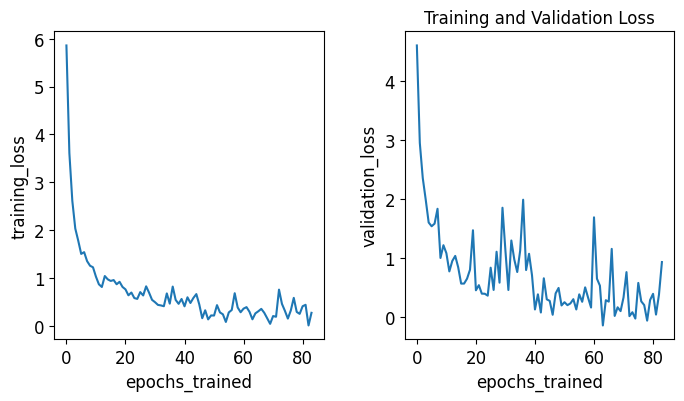

In [14]:
fig, axes = plot_summary(
    inference1, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

#### SimBac observations

In [34]:
theta1_500 = np.full((100, num_posterior_samples, 2), np.nan)
theta1_2000 = np.full((100, num_posterior_samples, 2), np.nan)
theta1_6000 = np.full((100, num_posterior_samples, 2), np.nan)

theta1_500.shape, theta1_2000.shape, theta1_6000.shape

((100, 1000, 2), (100, 1000, 2), (100, 1000, 2))

In [35]:
for i in range(100):
    x_obs = torch.tensor(x_500_SB[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior1.sample((num_posterior_samples,), x=x_obs[exact_col], show_progress_bars=False)
    theta1_500[i, :, :] = theta_post.cpu().numpy()

In [36]:
for i in range(100):
    x_obs = torch.tensor(x_2000_SB[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior1.sample((num_posterior_samples,), x=x_obs[exact_col], show_progress_bars=False)
    theta1_2000[i, :, :] = theta_post.cpu().numpy()

In [37]:
for i in range(100):
    x_obs = torch.tensor(x_6000_SB[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior1.sample((num_posterior_samples,), x=x_obs[exact_col], show_progress_bars=False)
    theta1_6000[i, :, :] = theta_post.cpu().numpy()

In [40]:
df.loc[0, rho_cols] = evaluate_posterior_metrics(0.02, theta1_500[:, :, 0])
df.loc[0, L_cols] = evaluate_posterior_metrics(500, theta1_500[:, :, 1])

df.loc[1, rho_cols] = evaluate_posterior_metrics(0.02, theta1_2000[:, :, 0])
df.loc[1, L_cols] = evaluate_posterior_metrics(2000, theta1_2000[:, :, 1])

df.loc[2, rho_cols] = evaluate_posterior_metrics(0.02, theta1_6000[:, :, 0])
df.loc[2, L_cols] = evaluate_posterior_metrics(6000, theta1_6000[:, :, 1])

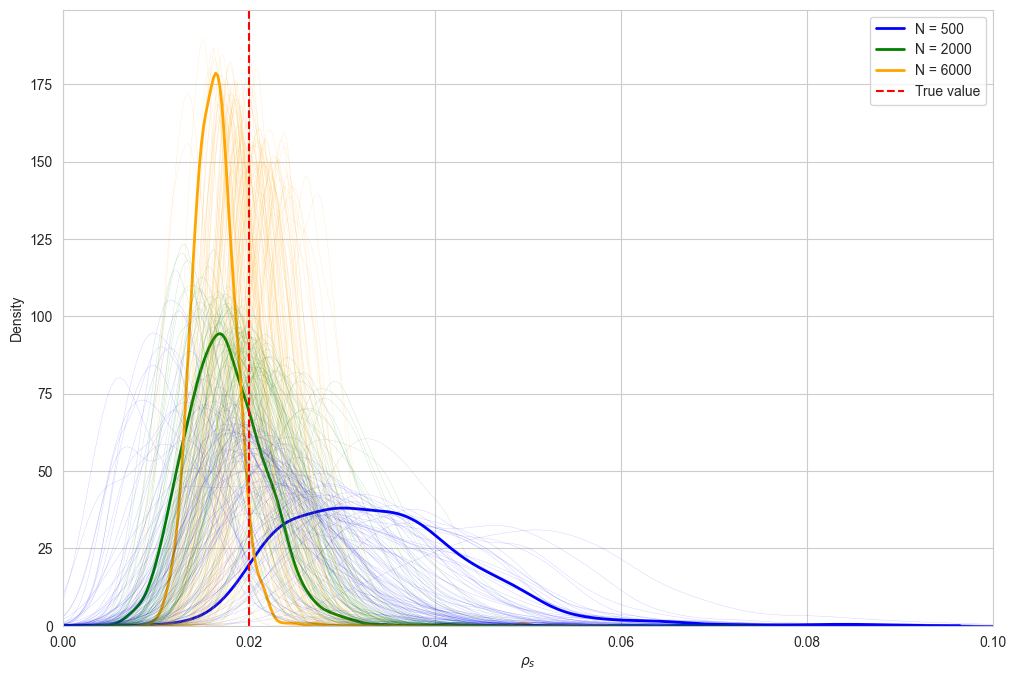

In [41]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta1_500[0, :, 0], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_2000[0, :, 0], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_6000[0, :, 0], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta1_500[i, :, 0], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_2000[i, :, 0], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_6000[i, :, 0], color='orange', linewidth=0.3, alpha=0.2)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

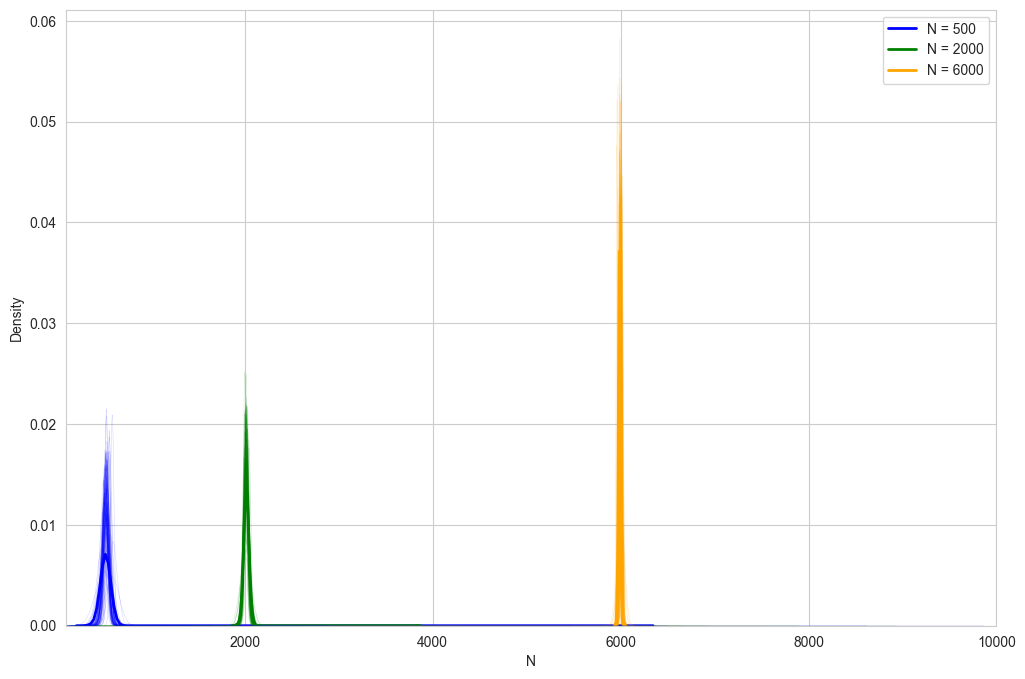

In [42]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta1_500[0, :, 1], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_2000[0, :, 1], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_6000[0, :, 1], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta1_500[i, :, 1], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_2000[i, :, 1], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_6000[i, :, 1], color='orange', linewidth=0.3, alpha=0.2)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

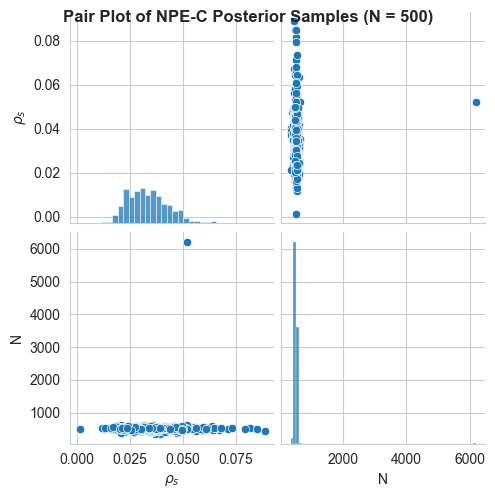

In [43]:
df_500 = pd.DataFrame(theta1_500[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

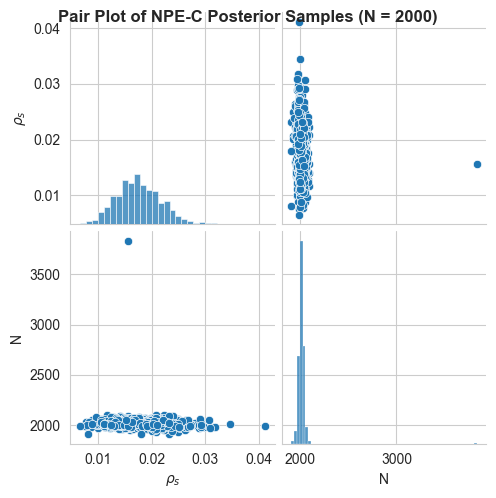

In [44]:
df_2000 = pd.DataFrame(theta1_2000[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

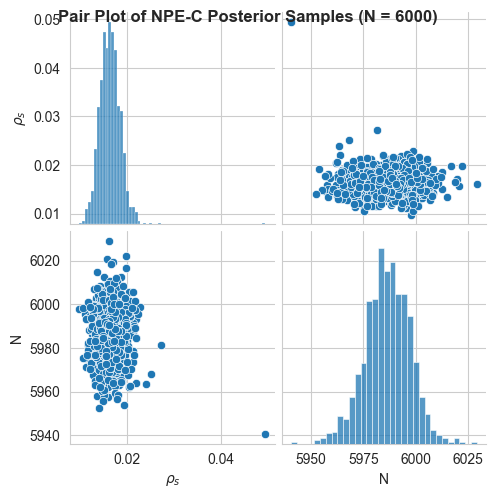

In [45]:
df_6000 = pd.DataFrame(theta1_6000[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

#### ClonalOrigin observations

In [46]:
theta1_500_CO = np.full((100, num_posterior_samples, 2), np.nan)
theta1_2000_CO = np.full((100, num_posterior_samples, 2), np.nan)
theta1_6000_CO = np.full((100, num_posterior_samples, 2), np.nan)

theta1_500_CO.shape, theta1_2000_CO.shape, theta1_6000_CO.shape

((100, 1000, 2), (100, 1000, 2), (100, 1000, 2))

In [47]:
for i in range(100):
    x_obs = torch.tensor(x_500_CO[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior1.sample((num_posterior_samples,), x=x_obs[exact_col], show_progress_bars=False)
    theta1_500_CO[i, :, :] = theta_post.cpu().numpy()

In [48]:
for i in range(100):
    x_obs = torch.tensor(x_2000_CO[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior1.sample((num_posterior_samples,), x=x_obs[exact_col], show_progress_bars=False)
    theta1_2000_CO[i, :, :] = theta_post.cpu().numpy()

In [49]:
for i in range(100):
    x_obs = torch.tensor(x_6000_CO[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior1.sample((num_posterior_samples,), x=x_obs[exact_col], show_progress_bars=False)
    theta1_6000_CO[i, :, :] = theta_post.cpu().numpy()

In [50]:
df.loc[3, rho_cols] = evaluate_posterior_metrics(0.02, theta1_500_CO[:, :, 0])
df.loc[3, L_cols] = evaluate_posterior_metrics(500, theta1_500_CO[:, :, 1])

df.loc[4, rho_cols] = evaluate_posterior_metrics(0.02, theta1_2000_CO[:, :, 0])
df.loc[4, L_cols] = evaluate_posterior_metrics(2000, theta1_2000_CO[:, :, 1])

df.loc[5, rho_cols] = evaluate_posterior_metrics(0.02, theta1_6000_CO[:, :, 0])
df.loc[5, L_cols] = evaluate_posterior_metrics(6000, theta1_6000_CO[:, :, 1])

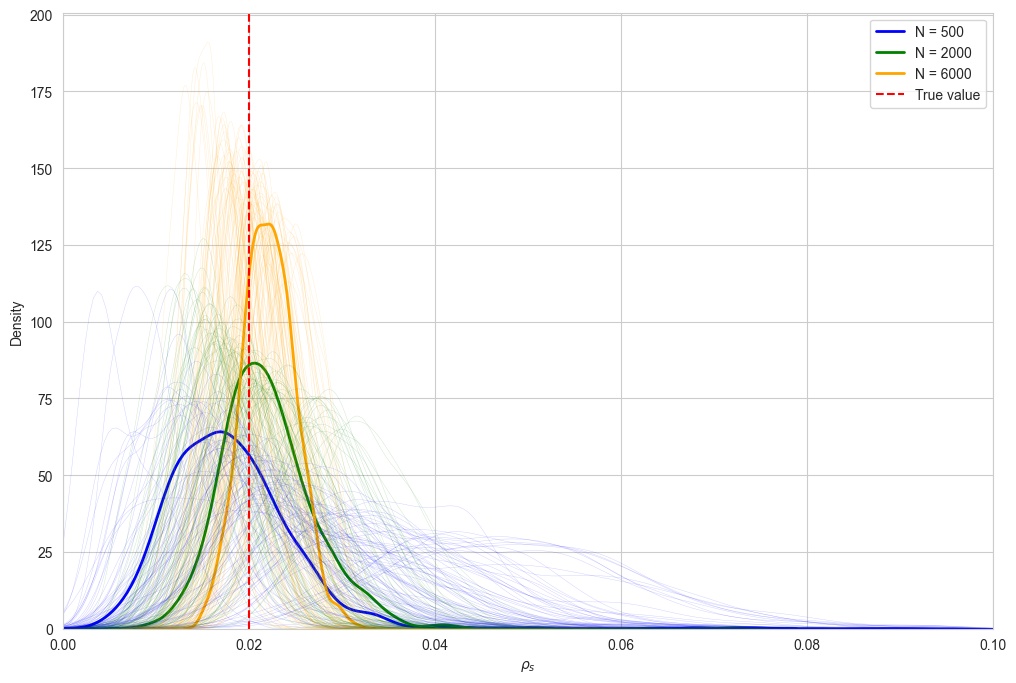

In [51]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta1_500_CO[0, :, 0], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_2000_CO[0, :, 0], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_6000_CO[0, :, 0], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta1_500_CO[i, :, 0], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_2000_CO[i, :, 0], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_6000_CO[i, :, 0], color='orange', linewidth=0.3, alpha=0.2)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

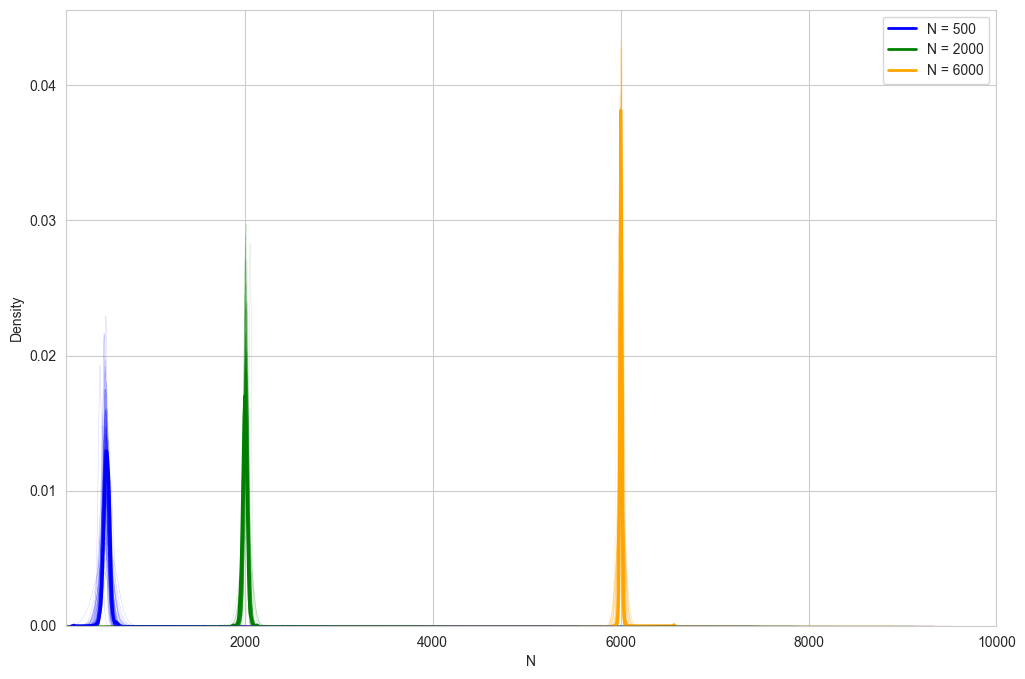

In [52]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta1_500_CO[0, :, 1], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_2000_CO[0, :, 1], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta1_6000_CO[0, :, 1], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta1_500_CO[i, :, 1], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_2000_CO[i, :, 1], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta1_6000_CO[i, :, 1], color='orange', linewidth=0.3, alpha=0.2)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

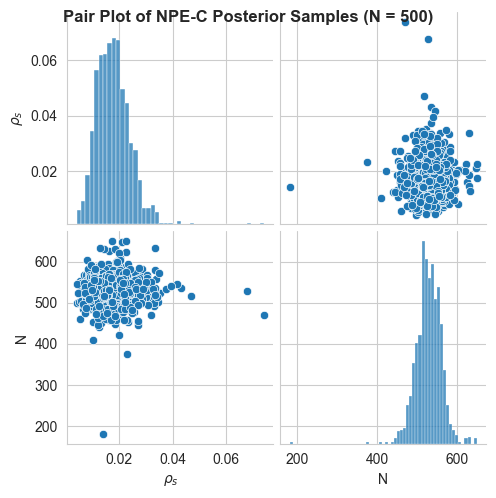

In [53]:
df_500 = pd.DataFrame(theta1_500_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

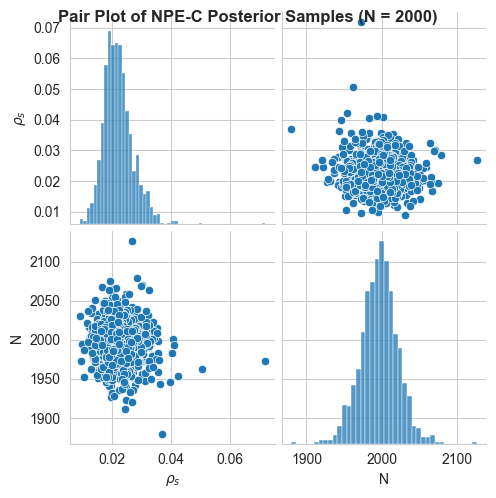

In [54]:
df_2000 = pd.DataFrame(theta1_2000_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

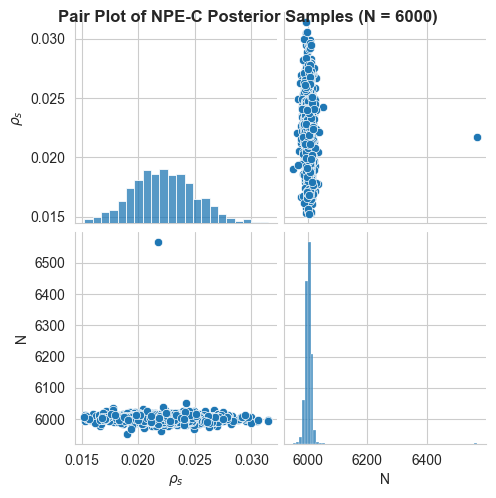

In [55]:
df_6000 = pd.DataFrame(theta1_6000_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

### Using simulation of proportion values

In [56]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference2 = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [57]:
prop_col = list(range(8, 16)) + list(range(24, 32)) + list(range(32, 46))
x2 = x[:, prop_col]

x2.shape, x2.dtype

(torch.Size([20000, 30]), torch.float32)

In [58]:
density_estimator2 = inference2.append_simulations(theta, x2).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior2 = inference2.build_posterior(density_estimator2)

 Neural network successfully converged after 134 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-06-15T11_07_19.369369' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


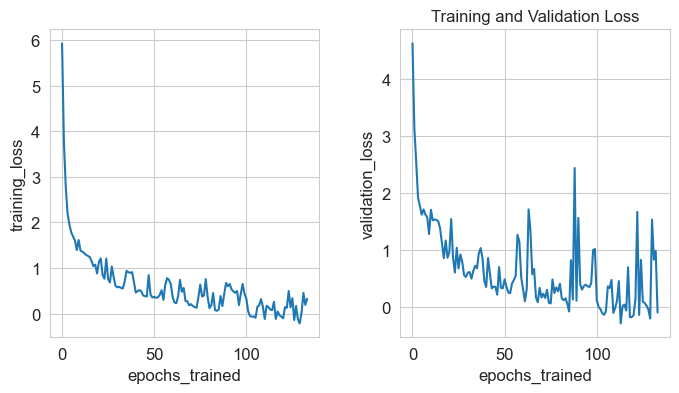

In [59]:
fig, axes = plot_summary(
    inference2, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

#### SimBac observations

In [60]:
theta2_500 = np.full((100, num_posterior_samples, 2), np.nan)
theta2_2000 = np.full((100, num_posterior_samples, 2), np.nan)
theta2_6000 = np.full((100, num_posterior_samples, 2), np.nan)

theta2_500.shape, theta2_2000.shape, theta2_6000.shape

((100, 1000, 2), (100, 1000, 2), (100, 1000, 2))

In [61]:
for i in range(100):
    x_obs = torch.tensor(x_500_SB[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior2.sample((num_posterior_samples,), x=x_obs[prop_col], show_progress_bars=False)
    theta2_500[i, :, :] = theta_post.cpu().numpy()

In [62]:
for i in range(100):
    x_obs = torch.tensor(x_2000_SB[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior2.sample((num_posterior_samples,), x=x_obs[prop_col], show_progress_bars=False)
    theta2_2000[i, :, :] = theta_post.cpu().numpy()

In [63]:
for i in range(100):
    x_obs = torch.tensor(x_6000_SB[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior2.sample((num_posterior_samples,), x=x_obs[prop_col], show_progress_bars=False)
    theta2_6000[i, :, :] = theta_post.cpu().numpy()

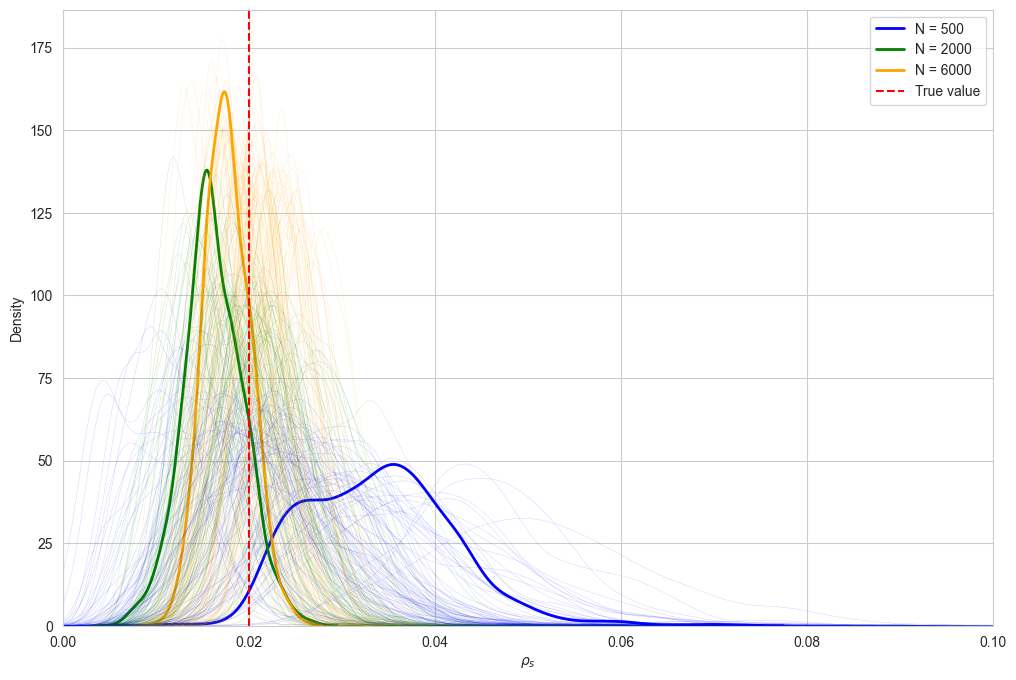

In [64]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta2_500[0, :, 0], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_2000[0, :, 0], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_6000[0, :, 0], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta2_500[i, :, 0], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_2000[i, :, 0], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_6000[i, :, 0], color='orange', linewidth=0.3, alpha=0.2)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

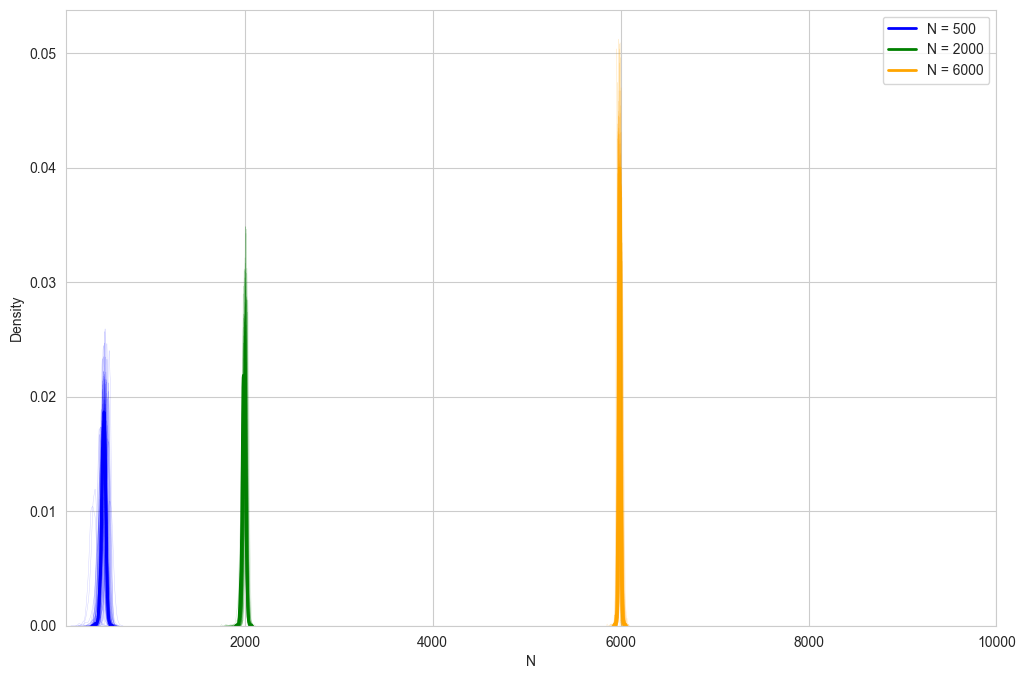

In [65]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta2_500[0, :, 1], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_2000[0, :, 1], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_6000[0, :, 1], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta2_500[i, :, 1], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_2000[i, :, 1], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_6000[i, :, 1], color='orange', linewidth=0.3, alpha=0.2)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

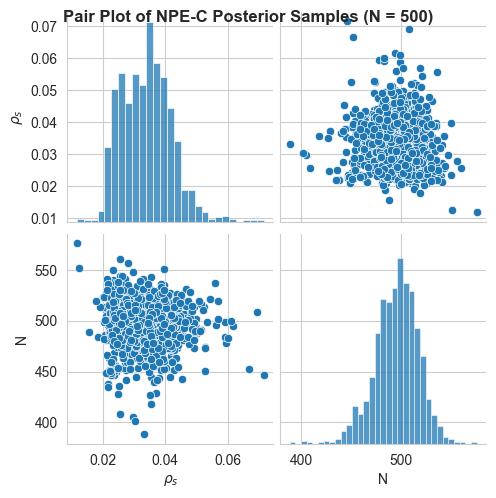

In [66]:
df_500 = pd.DataFrame(theta2_500[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

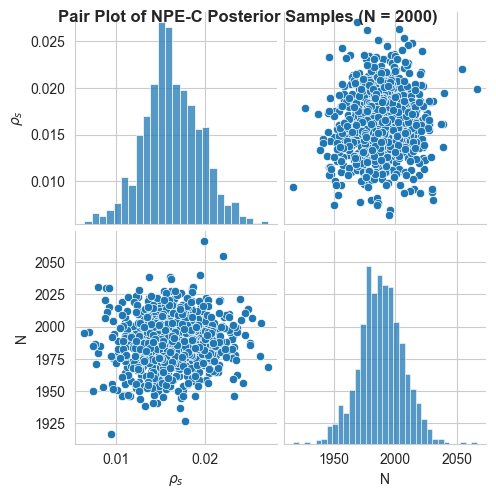

In [67]:
df_2000 = pd.DataFrame(theta2_2000[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

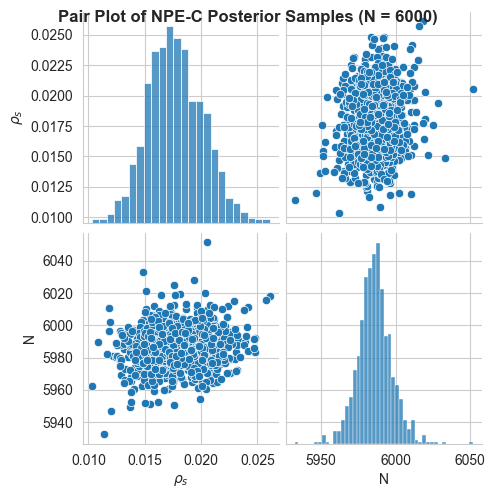

In [68]:
df_6000 = pd.DataFrame(theta2_6000[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

#### ClonalOrigin observations

In [69]:
theta2_500_CO = np.full((100, num_posterior_samples, 2), np.nan)
theta2_2000_CO = np.full((100, num_posterior_samples, 2), np.nan)
theta2_6000_CO = np.full((100, num_posterior_samples, 2), np.nan)

theta2_500_CO.shape, theta2_2000_CO.shape, theta2_6000_CO.shape

((100, 1000, 2), (100, 1000, 2), (100, 1000, 2))

In [70]:
for i in range(100):
    x_obs = torch.tensor(x_500_CO[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior2.sample((num_posterior_samples,), x=x_obs[prop_col], show_progress_bars=False)
    theta2_500_CO[i, :, :] = theta_post.cpu().numpy()

In [71]:
for i in range(100):
    x_obs = torch.tensor(x_2000_CO[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior2.sample((num_posterior_samples,), x=x_obs[prop_col], show_progress_bars=False)
    theta2_2000_CO[i, :, :] = theta_post.cpu().numpy()

In [72]:
for i in range(100):
    x_obs = torch.tensor(x_6000_CO[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior2.sample((num_posterior_samples,), x=x_obs[prop_col], show_progress_bars=False)
    theta2_6000_CO[i, :, :] = theta_post.cpu().numpy()

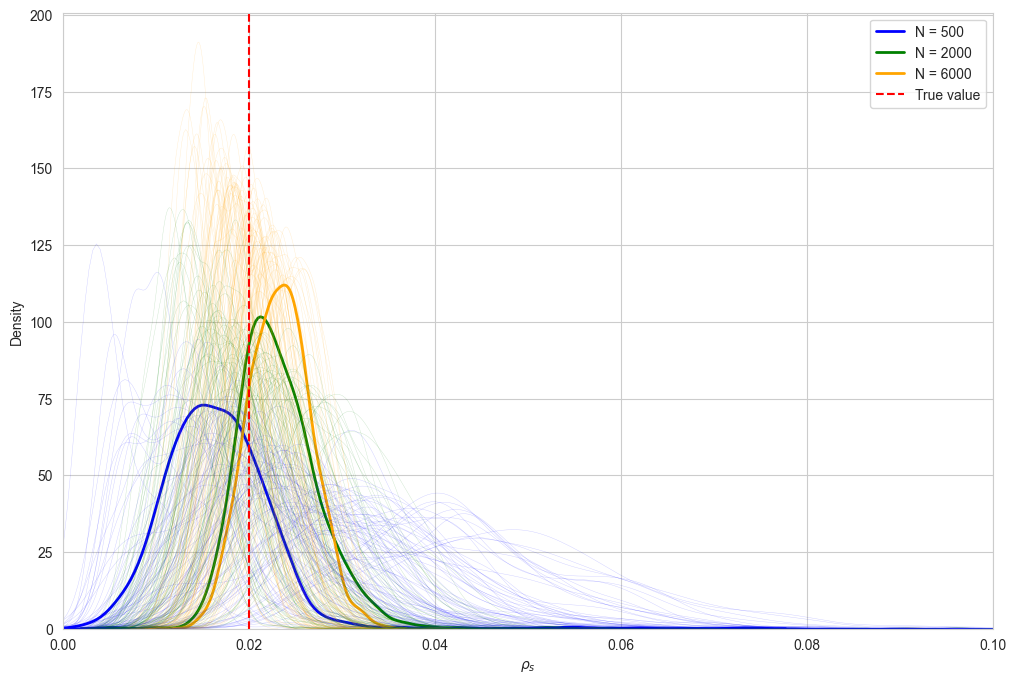

In [73]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta2_500_CO[0, :, 0], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_2000_CO[0, :, 0], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_6000_CO[0, :, 0], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta2_500_CO[i, :, 0], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_2000_CO[i, :, 0], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_6000_CO[i, :, 0], color='orange', linewidth=0.3, alpha=0.2)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

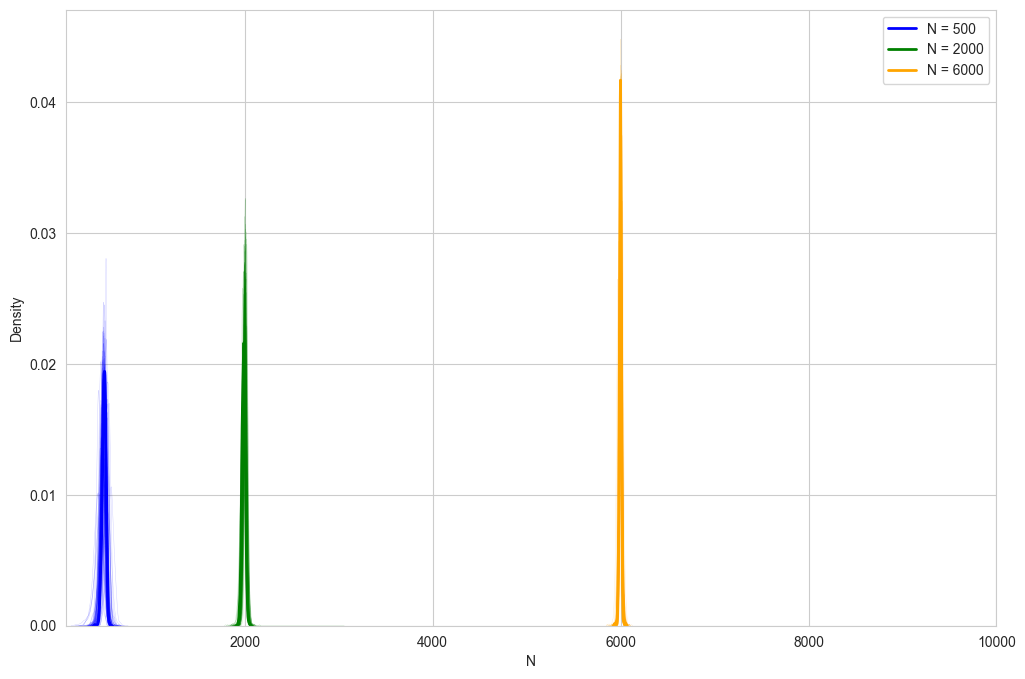

In [74]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta2_500_CO[0, :, 1], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_2000_CO[0, :, 1], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta2_6000_CO[0, :, 1], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta2_500_CO[i, :, 1], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_2000_CO[i, :, 1], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta2_6000_CO[i, :, 1], color='orange', linewidth=0.3, alpha=0.2)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

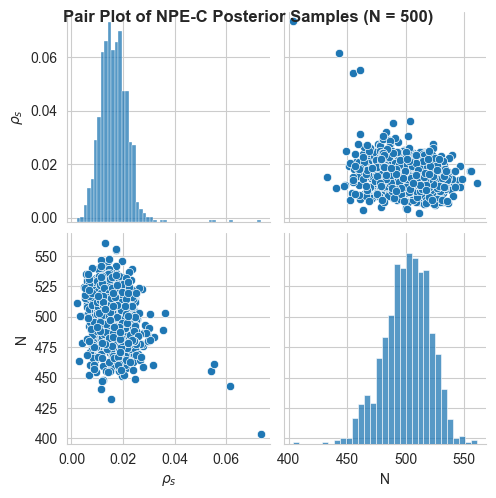

In [75]:
df_500 = pd.DataFrame(theta2_500_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

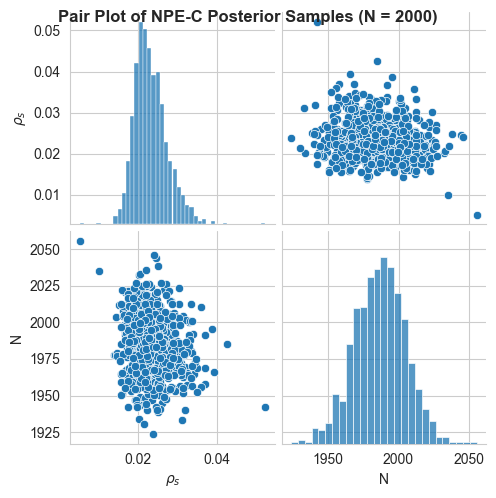

In [76]:
df_2000 = pd.DataFrame(theta2_2000_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

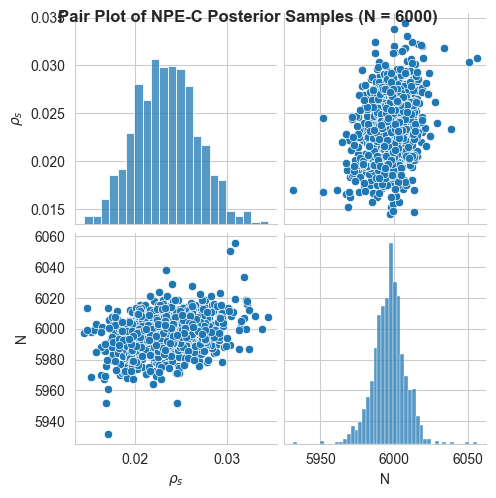

In [77]:
df_6000 = pd.DataFrame(theta2_6000_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

In [78]:
df.loc[6, rho_cols] = evaluate_posterior_metrics(0.02, theta2_500[:, :, 0])
df.loc[6, L_cols] = evaluate_posterior_metrics(500, theta2_500[:, :, 1])

df.loc[7, rho_cols] = evaluate_posterior_metrics(0.02, theta2_2000[:, :, 0])
df.loc[7, L_cols] = evaluate_posterior_metrics(2000, theta2_2000[:, :, 1])

df.loc[8, rho_cols] = evaluate_posterior_metrics(0.02, theta2_6000[:, :, 0])
df.loc[8, L_cols] = evaluate_posterior_metrics(6000, theta2_6000[:, :, 1])

df.loc[9, rho_cols] = evaluate_posterior_metrics(0.02, theta2_500_CO[:, :, 0])
df.loc[9, L_cols] = evaluate_posterior_metrics(500, theta2_500_CO[:, :, 1])

df.loc[10, rho_cols] = evaluate_posterior_metrics(0.02, theta2_2000_CO[:, :, 0])
df.loc[10, L_cols] = evaluate_posterior_metrics(2000, theta2_2000_CO[:, :, 1])

df.loc[11, rho_cols] = evaluate_posterior_metrics(0.02, theta2_6000_CO[:, :, 0])
df.loc[11, L_cols] = evaluate_posterior_metrics(6000, theta2_6000_CO[:, :, 1])

### Using all

In [79]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference3 = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [80]:
all_col = list(range(46))
x3 = x[:, all_col]

x3.shape, x3.dtype

(torch.Size([20000, 46]), torch.float32)

In [81]:
density_estimator3 = inference3.append_simulations(theta, x3).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior3 = inference3.build_posterior(density_estimator3)

 Neural network successfully converged after 102 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-06-15T11_14_45.714793' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


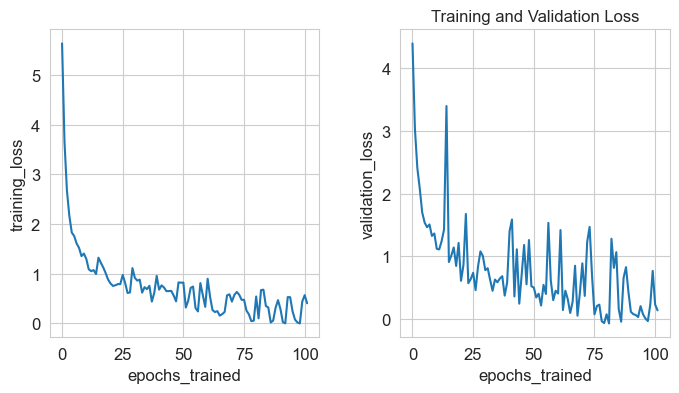

In [82]:
fig, axes = plot_summary(
    inference3, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

#### SimBac observations

In [83]:
theta3_500 = np.full((100, num_posterior_samples, 2), np.nan)
theta3_2000 = np.full((100, num_posterior_samples, 2), np.nan)
theta3_6000 = np.full((100, num_posterior_samples, 2), np.nan)

theta3_500.shape, theta3_2000.shape, theta3_6000.shape

((100, 1000, 2), (100, 1000, 2), (100, 1000, 2))

In [84]:
for i in range(100):
    x_obs = torch.tensor(x_500_SB[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior3.sample((num_posterior_samples,), x=x_obs[all_col], show_progress_bars=False)
    theta3_500[i, :, :] = theta_post.cpu().numpy()

In [85]:
for i in range(100):
    x_obs = torch.tensor(x_2000_SB[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior3.sample((num_posterior_samples,), x=x_obs[all_col], show_progress_bars=False)
    theta3_2000[i, :, :] = theta_post.cpu().numpy()

In [86]:
for i in range(100):
    x_obs = torch.tensor(x_6000_SB[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior3.sample((num_posterior_samples,), x=x_obs[all_col], show_progress_bars=False)
    theta3_6000[i, :, :] = theta_post.cpu().numpy()

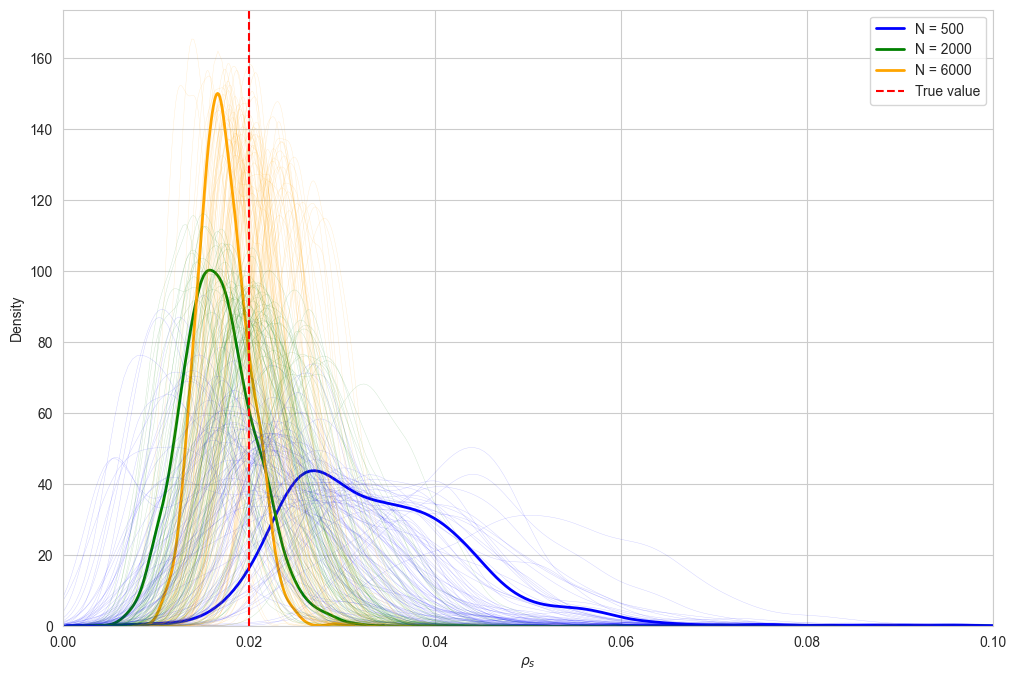

In [87]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta3_500[0, :, 0], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_2000[0, :, 0], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_6000[0, :, 0], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta3_500[i, :, 0], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_2000[i, :, 0], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_6000[i, :, 0], color='orange', linewidth=0.3, alpha=0.2)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

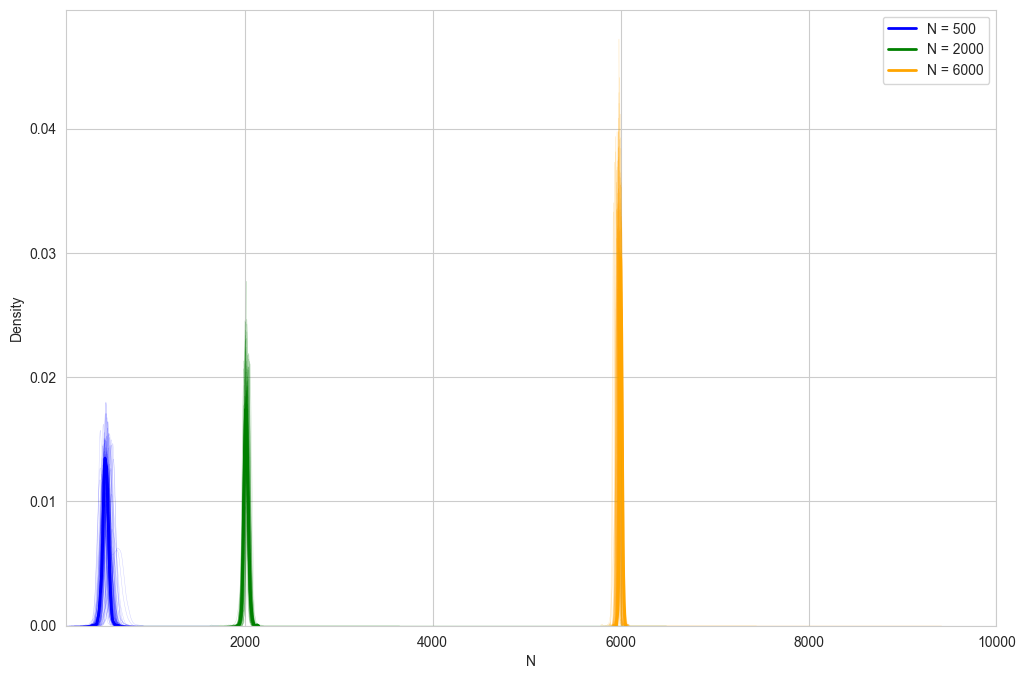

In [88]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta3_500[0, :, 1], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_2000[0, :, 1], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_6000[0, :, 1], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta3_500[i, :, 1], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_2000[i, :, 1], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_6000[i, :, 1], color='orange', linewidth=0.3, alpha=0.2)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

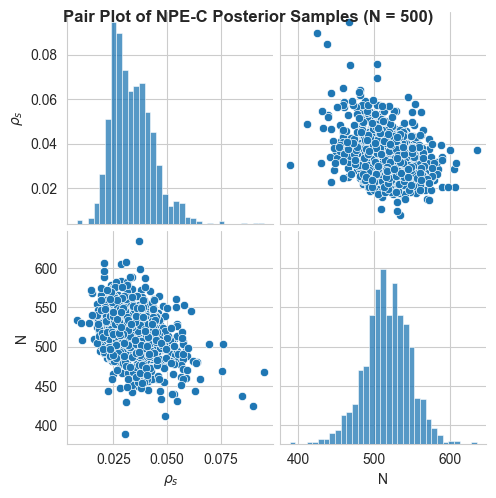

In [89]:
df_500 = pd.DataFrame(theta3_500[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

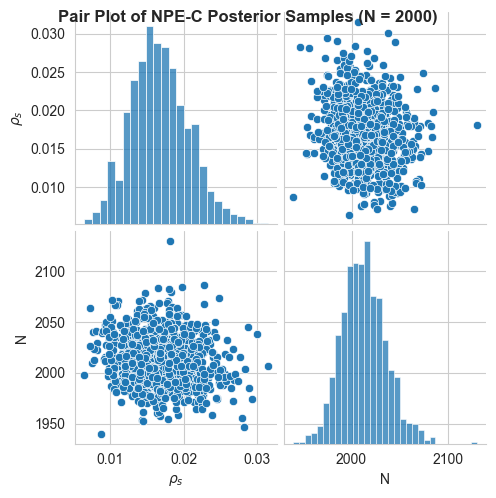

In [90]:
df_2000 = pd.DataFrame(theta3_2000[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

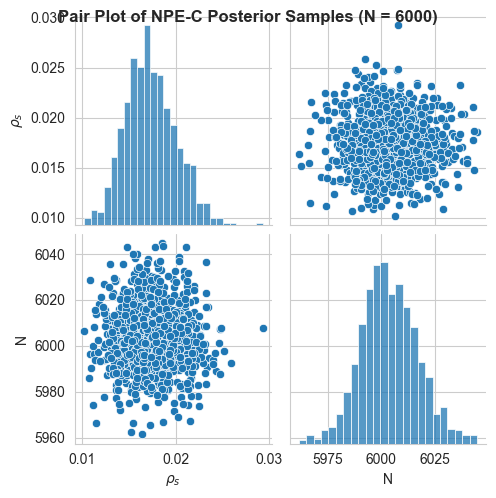

In [91]:
df_6000 = pd.DataFrame(theta3_6000[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

#### ClonalOrigin observations

In [92]:
theta3_500_CO = np.full((100, num_posterior_samples, 2), np.nan)
theta3_2000_CO = np.full((100, num_posterior_samples, 2), np.nan)
theta3_6000_CO = np.full((100, num_posterior_samples, 2), np.nan)

theta3_500_CO.shape, theta3_2000_CO.shape, theta3_6000_CO.shape

((100, 1000, 2), (100, 1000, 2), (100, 1000, 2))

In [93]:
for i in range(100):
    x_obs = torch.tensor(x_500_CO[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior3.sample((num_posterior_samples,), x=x_obs[all_col], show_progress_bars=False)
    theta3_500_CO[i, :, :] = theta_post.cpu().numpy()

In [94]:
for i in range(100):
    x_obs = torch.tensor(x_2000_CO[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior3.sample((num_posterior_samples,), x=x_obs[all_col], show_progress_bars=False)
    theta3_2000_CO[i, :, :] = theta_post.cpu().numpy()

In [95]:
for i in range(100):
    x_obs = torch.tensor(x_6000_CO[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior3.sample((num_posterior_samples,), x=x_obs[all_col], show_progress_bars=False)
    theta3_6000_CO[i, :, :] = theta_post.cpu().numpy()

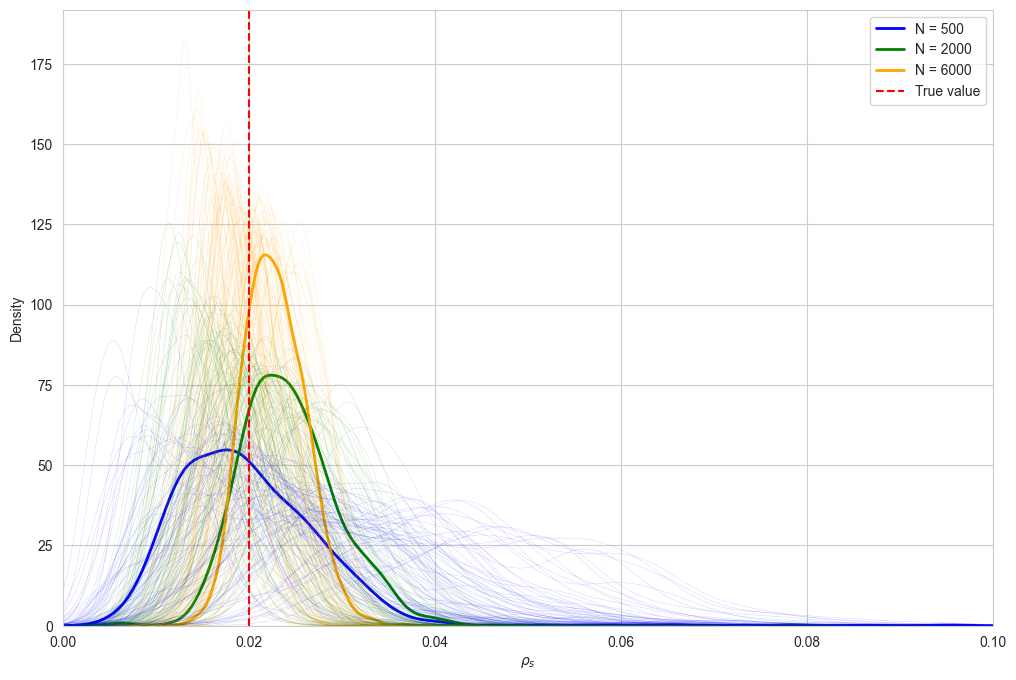

In [96]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta3_500_CO[0, :, 0], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_2000_CO[0, :, 0], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_6000_CO[0, :, 0], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta3_500_CO[i, :, 0], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_2000_CO[i, :, 0], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_6000_CO[i, :, 0], color='orange', linewidth=0.3, alpha=0.2)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

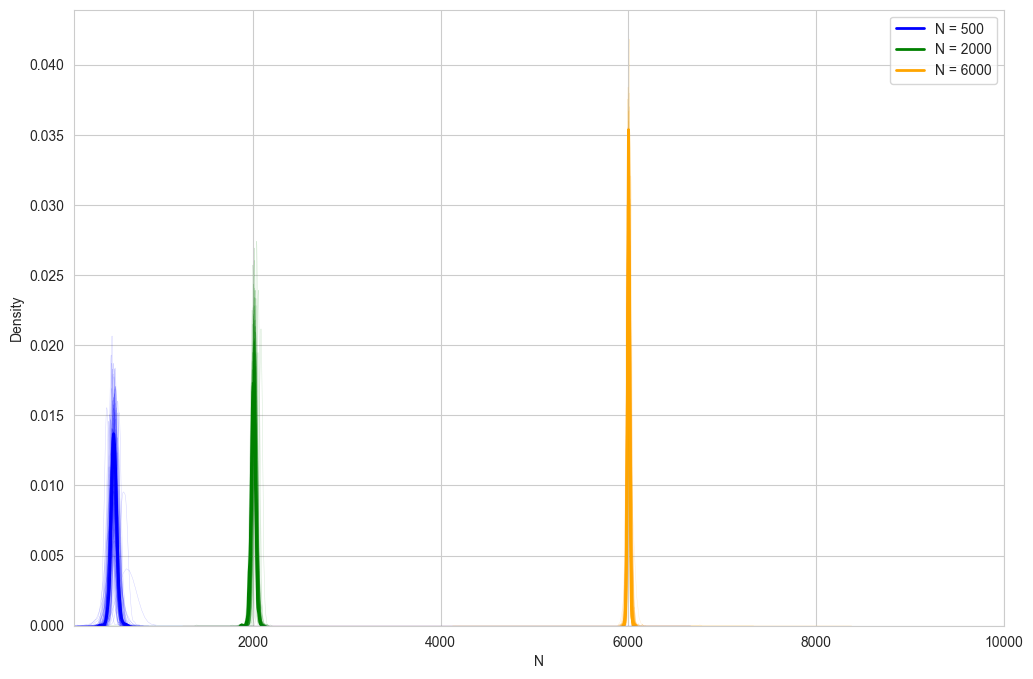

In [97]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta3_500_CO[0, :, 1], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_2000_CO[0, :, 1], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta3_6000_CO[0, :, 1], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta3_500_CO[i, :, 1], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_2000_CO[i, :, 1], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta3_6000_CO[i, :, 1], color='orange', linewidth=0.3, alpha=0.2)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

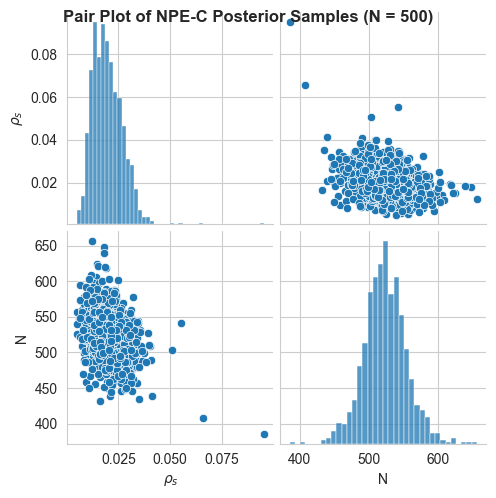

In [98]:
df_500 = pd.DataFrame(theta3_500_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

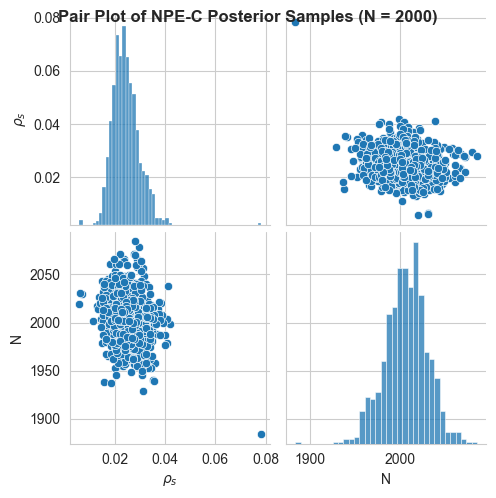

In [99]:
df_2000 = pd.DataFrame(theta3_2000_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

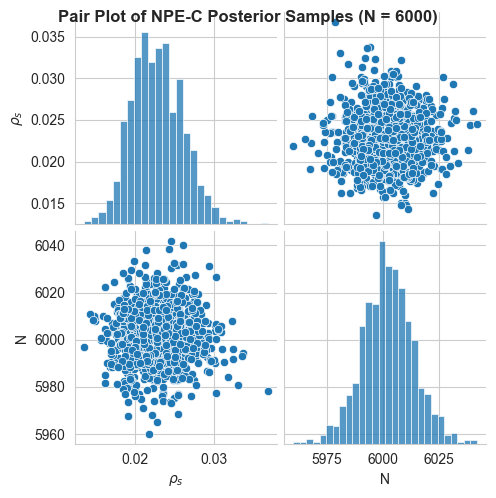

In [100]:
df_6000 = pd.DataFrame(theta3_6000_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

In [101]:
df.loc[12, rho_cols] = evaluate_posterior_metrics(0.02, theta3_500[:, :, 0])
df.loc[12, L_cols] = evaluate_posterior_metrics(500, theta3_500[:, :, 1])

df.loc[13, rho_cols] = evaluate_posterior_metrics(0.02, theta3_2000[:, :, 0])
df.loc[13, L_cols] = evaluate_posterior_metrics(2000, theta3_2000[:, :, 1])

df.loc[14, rho_cols] = evaluate_posterior_metrics(0.02, theta3_6000[:, :, 0])
df.loc[14, L_cols] = evaluate_posterior_metrics(6000, theta3_6000[:, :, 1])

df.loc[15, rho_cols] = evaluate_posterior_metrics(0.02, theta3_500_CO[:, :, 0])
df.loc[15, L_cols] = evaluate_posterior_metrics(500, theta3_500_CO[:, :, 1])

df.loc[16, rho_cols] = evaluate_posterior_metrics(0.02, theta3_2000_CO[:, :, 0])
df.loc[16, L_cols] = evaluate_posterior_metrics(2000, theta3_2000_CO[:, :, 1])

df.loc[17, rho_cols] = evaluate_posterior_metrics(0.02, theta3_6000_CO[:, :, 0])
df.loc[17, L_cols] = evaluate_posterior_metrics(6000, theta3_6000_CO[:, :, 1])

### More train data

In [103]:
theta1 = np.loadtxt('../data/ClonalOrigin_rho/theta1.csv', delimiter=",")
x1 = np.loadtxt('../data/ClonalOrigin_rho/x1.csv', delimiter=",")

theta2 = np.loadtxt('../data/ClonalOrigin_rho/theta2.csv', delimiter=",")
x2 = np.loadtxt('../data/ClonalOrigin_rho/x2.csv', delimiter=",")

theta3 = np.loadtxt('../data/ClonalOrigin_rho/theta3.csv', delimiter=",")
x3 = np.loadtxt('../data/ClonalOrigin_rho/x3.csv', delimiter=",")

theta4 = np.loadtxt('../data/ClonalOrigin_rho/theta4.csv', delimiter=",")
x4 = np.loadtxt('../data/ClonalOrigin_rho/x4.csv', delimiter=",")

x = np.vstack([x1, x2, x3, x4])
theta = np.vstack([theta1, theta2, theta3, theta4])

print(theta.shape, x.shape)

(50000, 2) (50000, 46)


In [104]:
theta = torch.tensor(theta, device=torch_device)
theta = theta.to(torch.float32)
theta_numpy = theta.cpu().numpy()

x = torch.tensor(x, device=torch_device)
x = x.to(torch.float32)
x_numpy = x.cpu().numpy()

In [108]:
seed = 100
num_posterior_samples=1000
learning_rate = 0.0005

inference4 = NPE_C(prior=prior, density_estimator="nsf", device=torch_device)
torch.manual_seed(seed)
np.random.seed(seed)

In [109]:
all_col = list(range(46))
x4 = x[:, all_col]

x4.shape, x4.dtype

(torch.Size([50000, 46]), torch.float32)

In [110]:
density_estimator4 = inference4.append_simulations(theta, x4).train(
    max_num_epochs=500, learning_rate=learning_rate
)
posterior4 = inference4.build_posterior(density_estimator4)

 Neural network successfully converged after 83 epochs.

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\u2008181\likelihood-free\python\sbi-logs\NPE_C\2026-06-15T11_25_31.610845' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


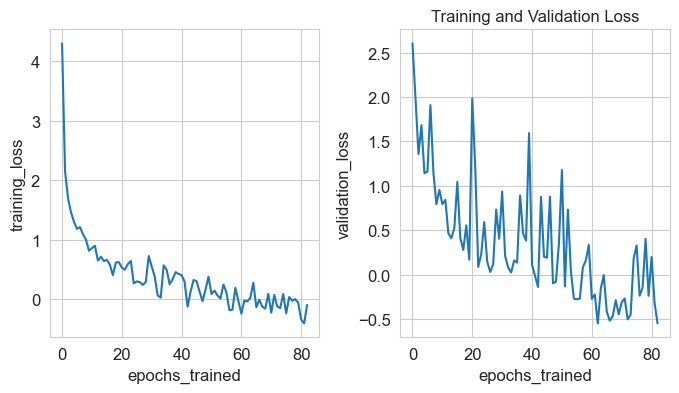

In [111]:
fig, axes = plot_summary(
    inference4, 
    tags=["training_loss", "validation_loss"], 
    figsize=(8, 4)
)
plt.title("Training and Validation Loss")
plt.show()

#### SimBac observations

In [112]:
theta4_500 = np.full((100, num_posterior_samples, 2), np.nan)
theta4_2000 = np.full((100, num_posterior_samples, 2), np.nan)
theta4_6000 = np.full((100, num_posterior_samples, 2), np.nan)

theta4_500.shape, theta4_2000.shape, theta4_6000.shape

((100, 1000, 2), (100, 1000, 2), (100, 1000, 2))

In [113]:
for i in range(100):
    x_obs = torch.tensor(x_500_SB[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior4.sample((num_posterior_samples,), x=x_obs[all_col], show_progress_bars=False)
    theta4_500[i, :, :] = theta_post.cpu().numpy()

In [114]:
for i in range(100):
    x_obs = torch.tensor(x_2000_SB[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior4.sample((num_posterior_samples,), x=x_obs[all_col], show_progress_bars=False)
    theta4_2000[i, :, :] = theta_post.cpu().numpy()

In [115]:
for i in range(100):
    x_obs = torch.tensor(x_6000_SB[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior4.sample((num_posterior_samples,), x=x_obs[all_col], show_progress_bars=False)
    theta4_6000[i, :, :] = theta_post.cpu().numpy()

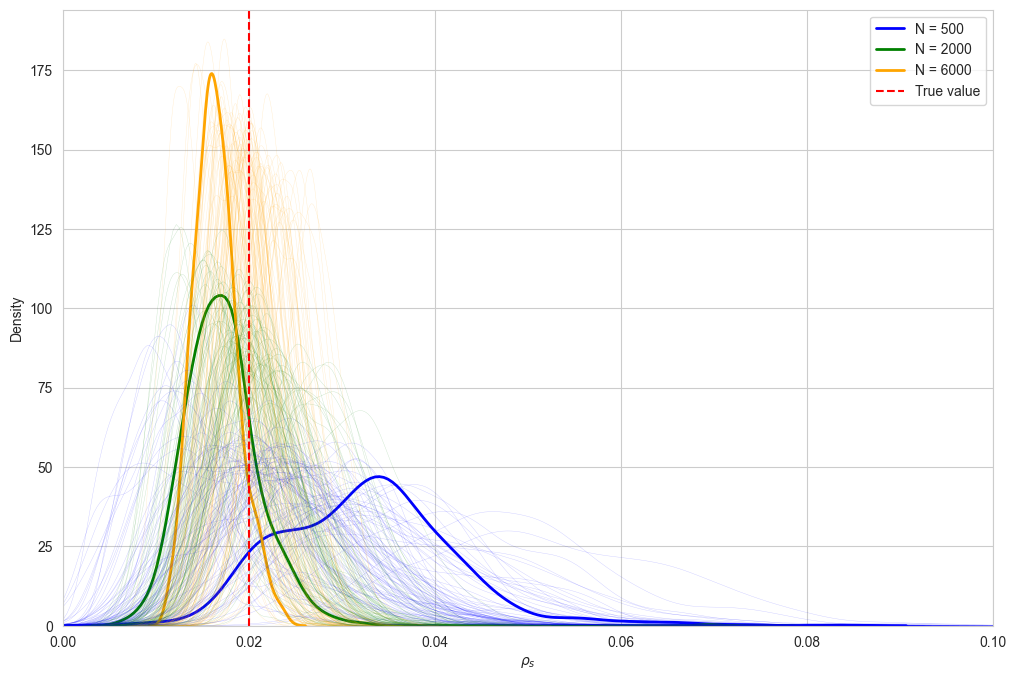

In [116]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta4_500[0, :, 0], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta4_2000[0, :, 0], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta4_6000[0, :, 0], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta4_500[i, :, 0], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta4_2000[i, :, 0], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta4_6000[i, :, 0], color='orange', linewidth=0.3, alpha=0.2)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

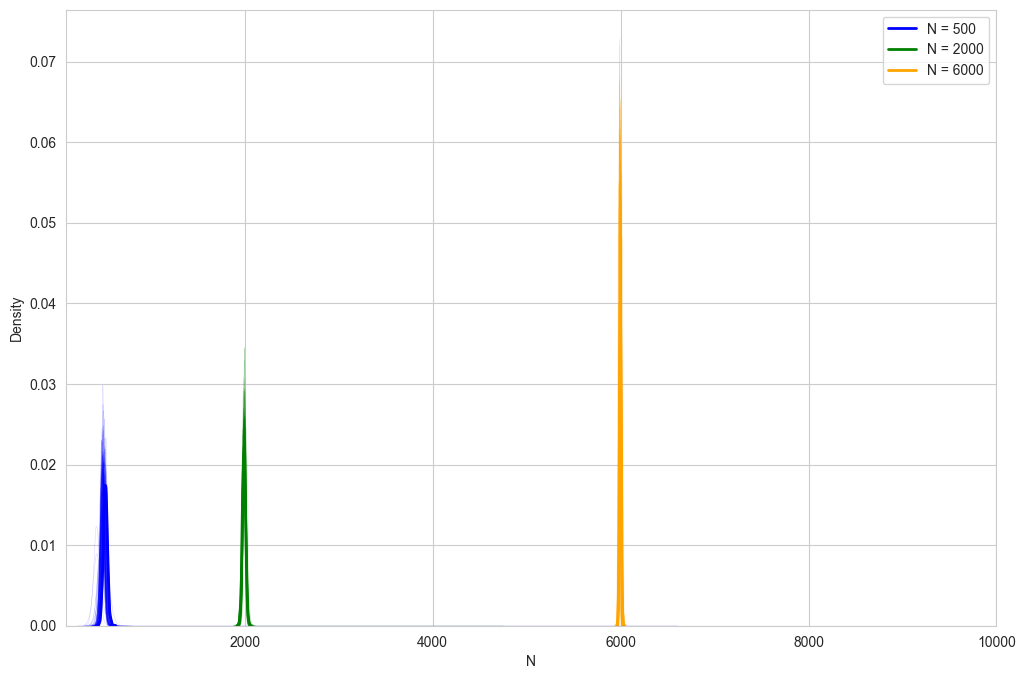

In [117]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta4_500[0, :, 1], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta4_2000[0, :, 1], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta4_6000[0, :, 1], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta4_500[i, :, 1], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta4_2000[i, :, 1], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta4_6000[i, :, 1], color='orange', linewidth=0.3, alpha=0.2)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

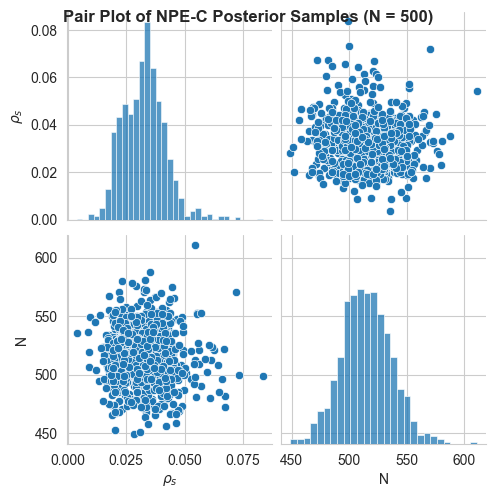

In [118]:
df_500 = pd.DataFrame(theta4_500[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

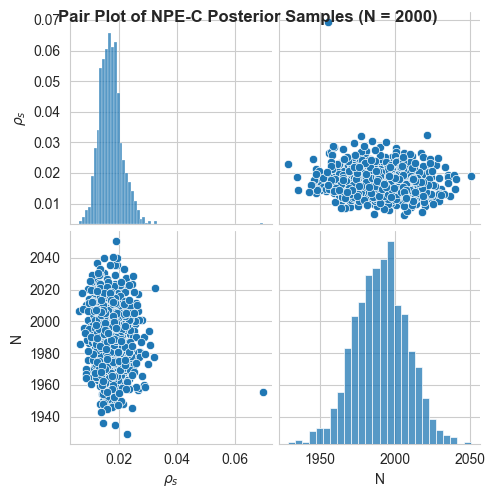

In [119]:
df_2000 = pd.DataFrame(theta4_2000[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

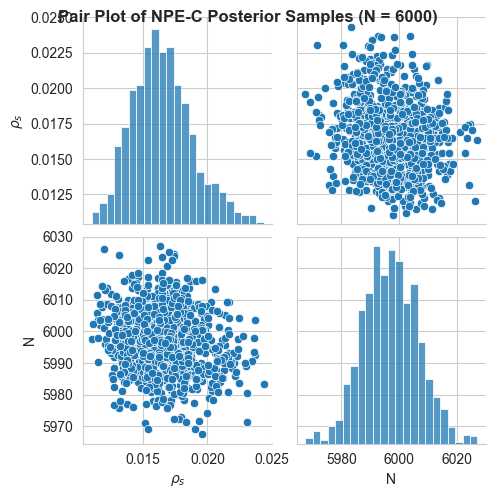

In [120]:
df_6000 = pd.DataFrame(theta4_6000[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

#### ClonalOrigin observations

In [121]:
theta4_500_CO = np.full((100, num_posterior_samples, 2), np.nan)
theta4_2000_CO = np.full((100, num_posterior_samples, 2), np.nan)
theta4_6000_CO = np.full((100, num_posterior_samples, 2), np.nan)

theta4_500_CO.shape, theta4_2000_CO.shape, theta4_6000_CO.shape

((100, 1000, 2), (100, 1000, 2), (100, 1000, 2))

In [122]:
for i in range(100):
    x_obs = torch.tensor(x_500_CO[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior4.sample((num_posterior_samples,), x=x_obs[all_col], show_progress_bars=False)
    theta4_500_CO[i, :, :] = theta_post.cpu().numpy()

In [123]:
for i in range(100):
    x_obs = torch.tensor(x_2000_CO[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior4.sample((num_posterior_samples,), x=x_obs[all_col], show_progress_bars=False)
    theta4_2000_CO[i, :, :] = theta_post.cpu().numpy()

In [124]:
for i in range(100):
    x_obs = torch.tensor(x_6000_CO[i, :], device=torch_device)
    x_obs = x_obs.to(torch.float32)
    theta_post = posterior4.sample((num_posterior_samples,), x=x_obs[all_col], show_progress_bars=False)
    theta4_6000_CO[i, :, :] = theta_post.cpu().numpy()

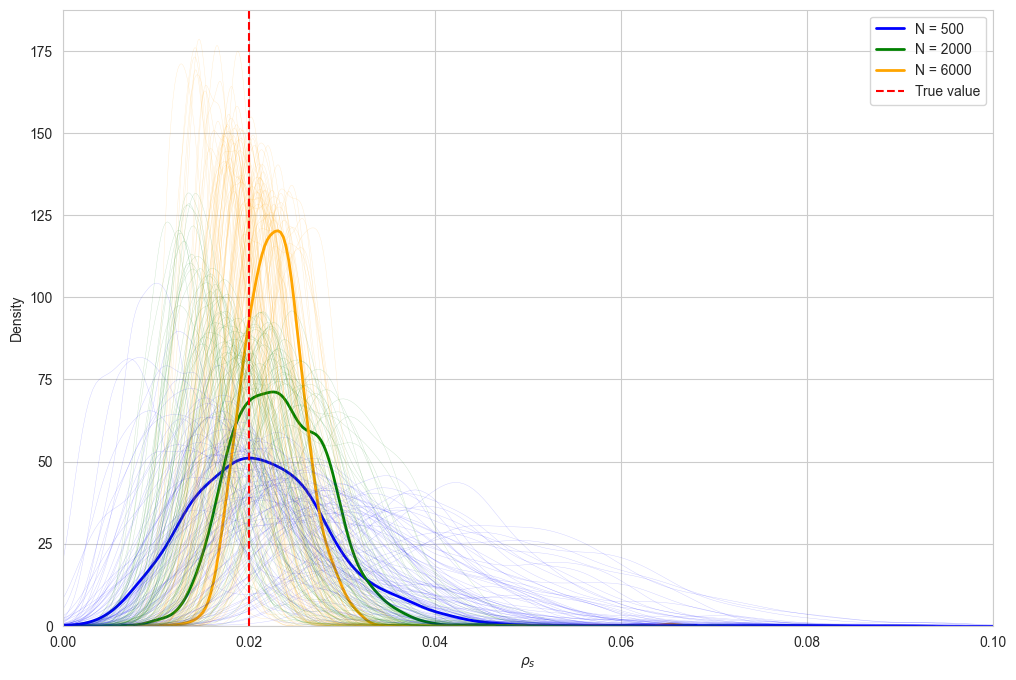

In [125]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta4_500_CO[0, :, 0], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta4_2000_CO[0, :, 0], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta4_6000_CO[0, :, 0], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta4_500_CO[i, :, 0], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta4_2000_CO[i, :, 0], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta4_6000_CO[i, :, 0], color='orange', linewidth=0.3, alpha=0.2)
plt.axvline(x=0.02, color='red', linestyle='dashed', label='True value')
plt.xlabel(r'$\rho_s$')
plt.xlim(0.0, 0.1)
plt.legend()
plt.show()

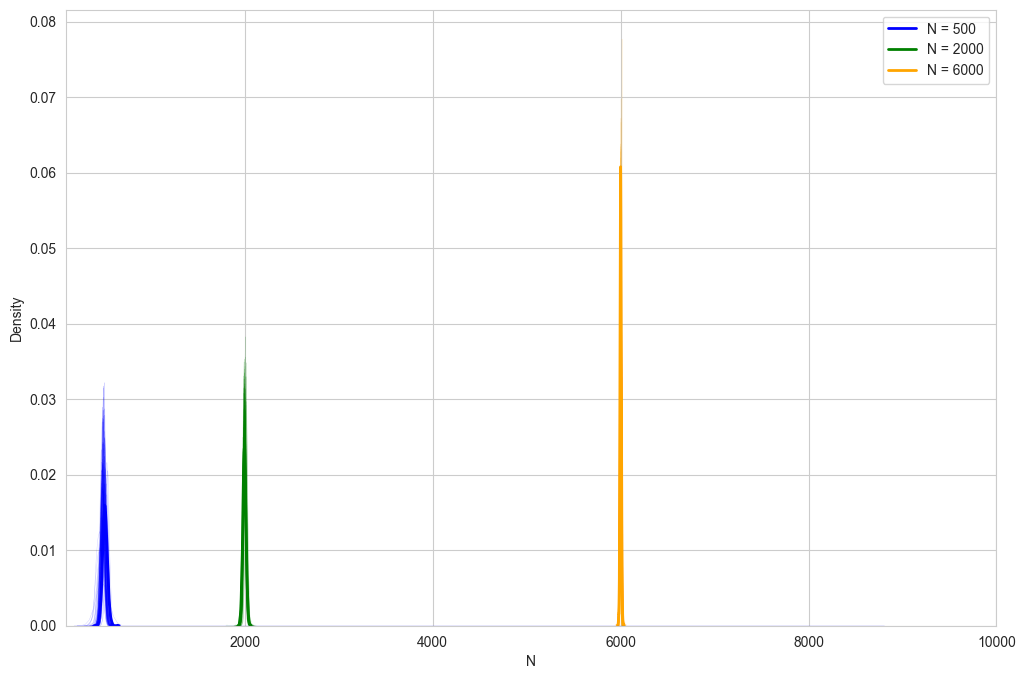

In [126]:
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')
sns.kdeplot(theta4_500_CO[0, :, 1], label='N = 500', color='blue', linewidth=2, alpha=1.0)
sns.kdeplot(theta4_2000_CO[0, :, 1], label='N = 2000', color='green', linewidth=2, alpha=1.0)
sns.kdeplot(theta4_6000_CO[0, :, 1], label='N = 6000', color='orange', linewidth=2, alpha=1.0)
for i in range(1, 100):
    sns.kdeplot(theta4_500_CO[i, :, 1], color='blue', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta4_2000_CO[i, :, 1], color='green', linewidth=0.3, alpha=0.2)
    sns.kdeplot(theta4_6000_CO[i, :, 1], color='orange', linewidth=0.3, alpha=0.2)
plt.xlabel('N')
plt.xlim(100.0, 10000.0)
plt.legend()
plt.show()

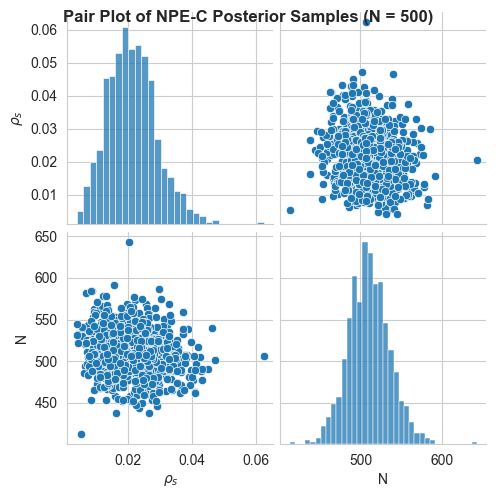

In [127]:
df_500 = pd.DataFrame(theta4_500_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_500)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 500)', fontsize=12, fontweight='bold')
plt.show()

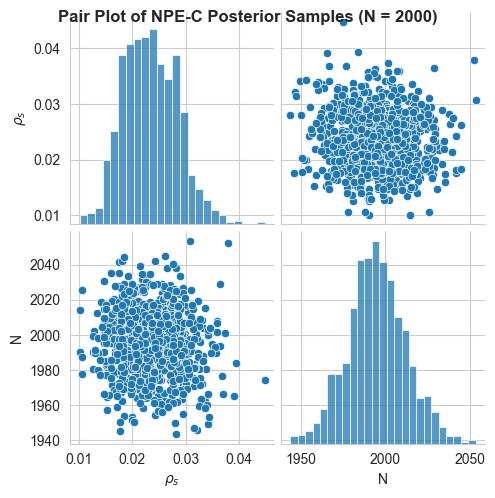

In [128]:
df_2000 = pd.DataFrame(theta4_2000_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_2000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 2000)', fontsize=12, fontweight='bold')
plt.show()

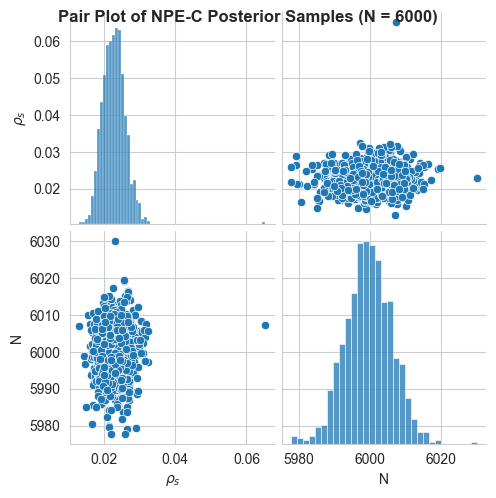

In [129]:
df_6000 = pd.DataFrame(theta4_6000_CO[0, :, :], columns=[r"$\rho_s$", "N"])
sns.pairplot(df_6000)
plt.suptitle('Pair Plot of NPE-C Posterior Samples (N = 6000)', fontsize=12, fontweight='bold')
plt.show()

In [130]:
df.loc[18, rho_cols] = evaluate_posterior_metrics(0.02, theta4_500[:, :, 0])
df.loc[18, L_cols] = evaluate_posterior_metrics(500, theta4_500[:, :, 1])

df.loc[19, rho_cols] = evaluate_posterior_metrics(0.02, theta4_2000[:, :, 0])
df.loc[19, L_cols] = evaluate_posterior_metrics(2000, theta4_2000[:, :, 1])

df.loc[20, rho_cols] = evaluate_posterior_metrics(0.02, theta4_6000[:, :, 0])
df.loc[20, L_cols] = evaluate_posterior_metrics(6000, theta4_6000[:, :, 1])

df.loc[21, rho_cols] = evaluate_posterior_metrics(0.02, theta4_500_CO[:, :, 0])
df.loc[21, L_cols] = evaluate_posterior_metrics(500, theta4_500_CO[:, :, 1])

df.loc[22, rho_cols] = evaluate_posterior_metrics(0.02, theta4_2000_CO[:, :, 0])
df.loc[22, L_cols] = evaluate_posterior_metrics(2000, theta4_2000_CO[:, :, 1])

df.loc[23, rho_cols] = evaluate_posterior_metrics(0.02, theta4_6000_CO[:, :, 0])
df.loc[23, L_cols] = evaluate_posterior_metrics(6000, theta4_6000_CO[:, :, 1])

In [132]:
df.to_csv('../output/sbi_metric_table.csv', index=False)